# Lab: Sequential MNIST - MLP vs CNN vs LSTM

## 1. Introduction: When does Recurrence Matter?

In this lab, we will compare three different neural network architectures on the **MNIST** dataset. While MNIST is typically treated as a computer vision problem (images), we can also treat it as a **sequence processing** problem.

We will compare:
1.  **MLP (Multi-Layer Perceptron)**: Treating the image as a flat vector of 784 pixels.
2.  **CNN (Convolutional Neural Network)**: Treating the image as a 2D grid (28x28), exploiting spatial locality.
3.  **LSTM (Long Short-Term Memory)**: Treating the image as a **sequence of 28 rows**, processing it top-to-bottom.

### Objectives
*   Understand the **Inductive Bias** of each architecture.
*   Compare the number of parameters required for each model.
*   Observe how an RNN (LSTM) processes static data sequentially.


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Configuration
BATCH_SIZE = 64
learning_rate = 0.005
num_epochs = 3
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cpu


In [3]:
# Transformations
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)) # Mean and Std of MNIST
])

# Download and Load Data
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, transform=transform, download=True)

train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train Size: {len(train_dataset)}")
print(f"Test Size: {len(test_dataset)}")


Train Size: 60000
Test Size: 10000


## 2. Visualizing Data: Image vs Sequence

A standard image is a 2D grid. However, an RNN sees it as a sequence of inputs over time steps.
For MNIST:
*   **Time Steps**: 28 (The number of rows)
*   **Input Size per Step**: 28 (The number of columns/pixels in that row)


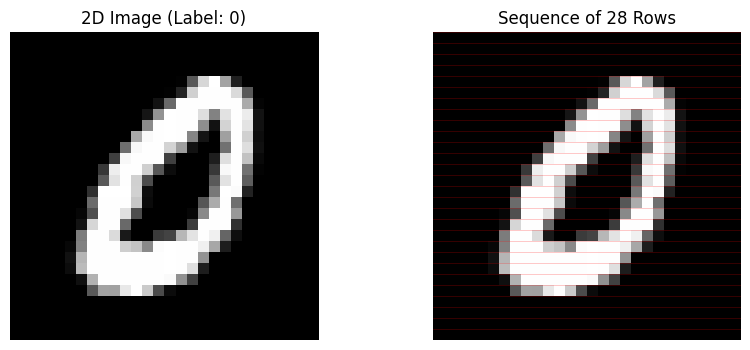

In [ ]:
# Get a single batch
images, labels = next(iter(train_loader))
img = images[0].squeeze() # Remove channel dim: [28, 28]

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# Plot 1: Standard Image
ax[0].imshow(img, cmap='gray')
ax[0].set_title(f"2D Image (Label: {labels[0]})")
ax[0].axis('off')


# Plot 2: Sequential View (Top to Bottom)
ax[1].imshow(img, cmap='gray')
ax[1].set_title("Sequence of 28 Rows")

for i in range(28):
    # Draw lines to show the "rows" the LSTM sees
    ax[1].axhline(i-0.5, color='red', alpha=0.3, linewidth=0.5)
ax[1].axis('off')

plt.show()


## 3. Defining the Architectures

### Model 1: MLP (The Baseline)
Flattens the 28x28 image into a single 784-vector. No concept of spatial grid or sequence order.


In [5]:
class MLP(nn.Module):
    def __init__(self, input_size=784, hidden_size=64, num_classes=10):
        super(MLP, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_classes)
    
    def forward(self, x):
        # x shape: [batch, 1, 28, 28] -> [batch, 784]
        out = self.flatten(x)
        out = self.fc1(out)
        out = self.relu(out)
        out = self.fc2(out)
        return out


### Model 2: CNN (The Spatial Expert)
Uses 2D Convolutions to detect edges and shapes. Efficient for images.


In [6]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        # Conv block 1
        self.layer1 = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        # Conv block 2
        self.layer2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        # Fully connected
        self.fc = nn.Linear(7 * 7 * 32, 10)
        
    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = out.reshape(out.size(0), -1) # Flatten
        out = self.fc(out)
        return out


### Model 3: LSTM (The Sequential Expert)
Processes the image row-by-row.
*   **Input**: Vector of size 28 (one row).
*   **Hidden State**: Updates 28 times.
*   **Output**: We take the output of the *last* time step.
*   **Parameter Sharing**: The same LSTM weights process every row.


In [7]:
class RNN_LSTM(nn.Module):
    def __init__(self, input_size=28, hidden_size=64, num_layers=1, num_classes=10):
        super(RNN_LSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)
    
    def forward(self, x):
        # x shape: [batch, 1, 28, 28]
        # We need: [batch, sequence_length, input_size] -> [batch, 28, 28]
        x = x.squeeze(1) # Remove the channel dimension
        
        # Initialize hidden state and cell state
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        
        # Forward propagate LSTM
        out, _ = self.lstm(x, (h0, c0)) 
        
        # out shape: [batch, seq_length, hidden_size]
        # Decode the hidden state of the last time step
        out = self.fc(out[:, -1, :])
        return out


In [8]:
def get_param_count(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [11]:
def train_and_eval(model, name="Model"):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    print(f"\n--- Training {name} ---")
    print(f"Parameters: {get_param_count(model):,}")
    
    for epoch in range(num_epochs):
        model.train()
        for i, (images, labels) in enumerate(train_loader):
            images = images.to(device)
            labels = labels.to(device)
            
            # Forward
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # Backward
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")
        
    # Evaluation
    model.eval()
    with torch.no_grad():
        correct = 0
        total = 0
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
        print(f"{name} Accuracy: {100 * correct / total:.2f}%")
    return model


## 4. Training and Comparison
We will train all three models for just 3 epochs to see learning speed and efficiency.


In [12]:
# 1. MLP
mlp_model = MLP()
train_and_eval(mlp_model, "MLP")

# 2. CNN
cnn_model = CNN()
train_and_eval(cnn_model, "CNN")

# 3. LSTM
lstm_model = RNN_LSTM()
train_and_eval(lstm_model, "LSTM")



--- Training MLP ---
Parameters: 50,890
Epoch [1/3], Loss: 0.1149
Epoch [2/3], Loss: 0.1506
Epoch [3/3], Loss: 0.2596
MLP Accuracy: 96.25%

--- Training CNN ---
Parameters: 20,490
Epoch [1/3], Loss: 0.1276
Epoch [2/3], Loss: 0.0690
Epoch [3/3], Loss: 0.0319
CNN Accuracy: 98.62%

--- Training LSTM ---
Parameters: 24,714
Epoch [1/3], Loss: 0.2783
Epoch [2/3], Loss: 0.1982
Epoch [3/3], Loss: 0.0052
LSTM Accuracy: 97.59%


RNN_LSTM(
  (lstm): LSTM(28, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=10, bias=True)
)

## 5. Inference Test
Let's visually check predictions on a single sample.


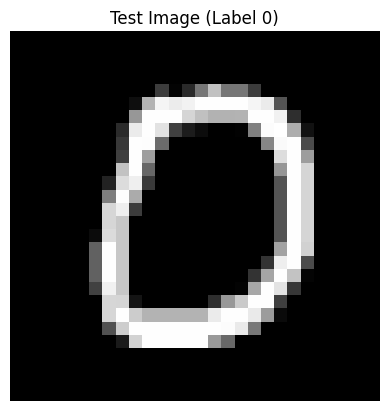

Model: MLP
True Label: 0
Predicted: 0
Confidence: 1.0000
--------------------
Model: CNN
True Label: 0
Predicted: 0
Confidence: 1.0000
--------------------
Model: LSTM
True Label: 0
Predicted: 0
Confidence: 0.9998
--------------------


In [13]:
def inference_test(model, img, label, name):
    model.eval()
    with torch.no_grad():
        # Add batch dim: [1, 1, 28, 28]
        img_batch = img.unsqueeze(0).to(device)
        outputs = model(img_batch)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs.data, 1)
        
        print(f"Model: {name}")
        print(f"True Label: {label}")
        print(f"Predicted: {predicted.item()}")
        print(f"Confidence: {probabilities[0][predicted.item()]:.4f}")
        print("-" * 20)

# Pick a test image
sample_idx = 10
test_img = test_dataset[sample_idx][0]
test_label = test_dataset[sample_idx][1]

plt.imshow(test_img.squeeze(), cmap='gray')
plt.title(f"Test Image (Label {test_label})")
plt.axis('off')
plt.show()

inference_test(mlp_model, test_img, test_label, "MLP")
inference_test(cnn_model, test_img, test_label, "CNN")
inference_test(lstm_model, test_img, test_label, "LSTM")


## 6. Conclusion

*   **CNNs** are specialized for grid data and usually achieve the highest accuracy with efficient weight sharing (convolutions).
*   **LSTMs** can process images by treating them as sequences. This demonstrates that they can capture long-term dependencies (from top row to bottom row), but they are computationally more expensive per step because they cannot be parallelized as easily as CNNs.
*   **MLPs** are general purpose but ignore structure, requiring more parameters to learn spatial relationships.

**Takeaway**: Use CNNs for images. Use LSTMs/RNNs when the *sequence ordering* matters (e.g., text, audio, time-series).
